Dataset Shape: (442, 10)

First 5 rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

Target Class Counts:
Class
1    221
0    221
Name: count, dtype: int64

POLYNOMIAL KERNEL SVM RESULTS
Training Accuracy : 0.83
Testing Accuracy  : 0.6517

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.62      0.64        45
           1     

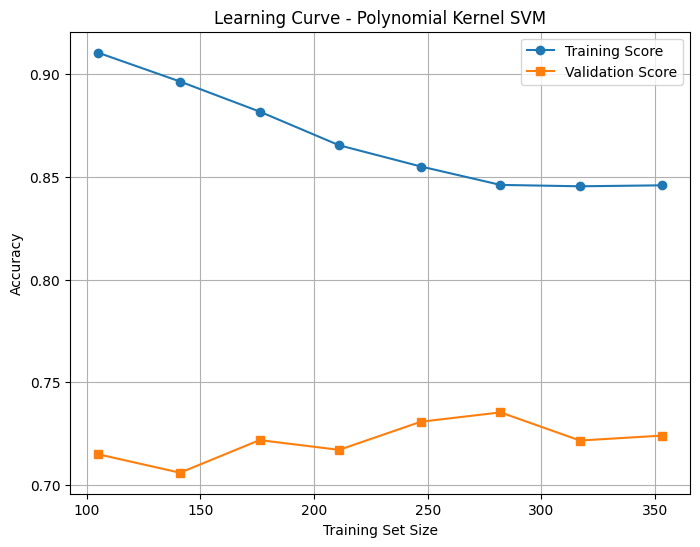


POLYNOMIAL KERNEL SVM - DEGREE COMPARISON
Degree      Train Acc      Test Acc       Remarks
2           0.7875         0.7191         Balanced
3           0.8300         0.6517         Overfitting
4           0.8839         0.7191         Overfitting
5           0.9292         0.7753         Overfitting

POLYNOMIAL KERNEL SVM - C VALUE COMPARISON
C Value     Train Acc      Test Acc       Remarks
0.01        0.7564         0.7303         Balanced
0.1         0.7847         0.7303         Balanced
1           0.8300         0.6517         Overfitting
10          0.8782         0.6292         Overfitting
100         0.9547         0.6629         Overfitting

POLYNOMIAL KERNEL SVM - GAMMA VALUE COMPARISON
Gamma       Train Acc      Test Acc       Remarks
0.001       0.7479         0.7640         Balanced
0.01        0.7592         0.7303         Balanced
0.1         0.8300         0.6517         Overfitting
1           0.9887         0.5730         Overfitting


In [2]:
# Programming Assignment 36
# Polynomial Kernel Support Vector Machine
# Dataset used: Diabetes Dataset
# Considering bias, variance, overfitting and underfitting issues

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --------------------------------------------------
# 1. Load dataset
# --------------------------------------------------
data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y_reg = pd.Series(data.target, name="Target")

# Convert regression target into classification target
# 0 -> Below median
# 1 -> Above median
y = pd.Series((y_reg > y_reg.median()).astype(int), name="Class")

print("Dataset Shape:", X.shape)
print("\nFirst 5 rows:")
print(X.head())
print("\nTarget Class Counts:")
print(y.value_counts())

# --------------------------------------------------
# 2. Split dataset into training and testing sets
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --------------------------------------------------
# 3. Standardize features
# --------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_full = StandardScaler().fit_transform(X)

# --------------------------------------------------
# 4. Train Polynomial Kernel SVM
# --------------------------------------------------
poly_svm = SVC(kernel='poly', degree=3, C=1.0, gamma='scale', coef0=1, random_state=42)
poly_svm.fit(X_train_scaled, y_train)

# --------------------------------------------------
# 5. Predictions
# --------------------------------------------------
y_train_pred = poly_svm.predict(X_train_scaled)
y_test_pred = poly_svm.predict(X_test_scaled)

# --------------------------------------------------
# 6. Accuracy Calculation
# --------------------------------------------------
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\n" + "=" * 60)
print("POLYNOMIAL KERNEL SVM RESULTS")
print("=" * 60)
print("Training Accuracy :", round(train_acc, 4))
print("Testing Accuracy  :", round(test_acc, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# --------------------------------------------------
# 7. Bias, Variance, Overfitting, Underfitting Analysis
# --------------------------------------------------
print("\n" + "-" * 60)
print("Bias-Variance Analysis")
print("-" * 60)
print("Training Accuracy :", round(train_acc, 4))
print("Testing Accuracy  :", round(test_acc, 4))
print("Difference        :", round(abs(train_acc - test_acc), 4))

if train_acc < 0.75 and test_acc < 0.75:
    print("HIGH BIAS -> Model is likely UNDERFITTING")
elif (train_acc - test_acc) > 0.10:
    print("HIGH VARIANCE -> Model is likely OVERFITTING")
else:
    print("Model has a reasonable bias-variance balance")

# --------------------------------------------------
# 8. Learning Curve
# --------------------------------------------------
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    SVC(kernel='poly', degree=3, C=1.0, gamma='scale', coef0=1, random_state=42),
    X_scaled_full,
    y,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=np.linspace(0.3, 1.0, 8),
    shuffle=True,
    random_state=42
)

train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_scores_mean, marker='s', label='Validation Score')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Polynomial Kernel SVM")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# 9. Degree Comparison
# --------------------------------------------------
print("\n" + "=" * 70)
print("POLYNOMIAL KERNEL SVM - DEGREE COMPARISON")
print("=" * 70)
print(f"{'Degree':<12}{'Train Acc':<15}{'Test Acc':<15}{'Remarks'}")

degree_values = [2, 3, 4, 5]

for d in degree_values:
    model = SVC(kernel='poly', degree=d, C=1.0, gamma='scale', coef0=1, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    tr_acc = accuracy_score(y_train, train_pred)
    te_acc = accuracy_score(y_test, test_pred)

    if tr_acc < 0.75 and te_acc < 0.75:
        remark = "Underfitting"
    elif (tr_acc - te_acc) > 0.10:
        remark = "Overfitting"
    else:
        remark = "Balanced"

    print(f"{d:<12}{tr_acc:<15.4f}{te_acc:<15.4f}{remark}")

# --------------------------------------------------
# 10. C Value Comparison
# --------------------------------------------------
print("\n" + "=" * 70)
print("POLYNOMIAL KERNEL SVM - C VALUE COMPARISON")
print("=" * 70)
print(f"{'C Value':<12}{'Train Acc':<15}{'Test Acc':<15}{'Remarks'}")

c_values = [0.01, 0.1, 1, 10, 100]

for c in c_values:
    model = SVC(kernel='poly', degree=3, C=c, gamma='scale', coef0=1, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    tr_acc = accuracy_score(y_train, train_pred)
    te_acc = accuracy_score(y_test, test_pred)

    if tr_acc < 0.75 and te_acc < 0.75:
        remark = "Underfitting"
    elif (tr_acc - te_acc) > 0.10:
        remark = "Overfitting"
    else:
        remark = "Balanced"

    print(f"{c:<12}{tr_acc:<15.4f}{te_acc:<15.4f}{remark}")

# --------------------------------------------------
# 11. Gamma Comparison
# --------------------------------------------------
print("\n" + "=" * 70)
print("POLYNOMIAL KERNEL SVM - GAMMA VALUE COMPARISON")
print("=" * 70)
print(f"{'Gamma':<12}{'Train Acc':<15}{'Test Acc':<15}{'Remarks'}")

gamma_values = [0.001, 0.01, 0.1, 1]

for g in gamma_values:
    model = SVC(kernel='poly', degree=3, C=1.0, gamma=g, coef0=1, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    tr_acc = accuracy_score(y_train, train_pred)
    te_acc = accuracy_score(y_test, test_pred)

    if tr_acc < 0.75 and te_acc < 0.75:
        remark = "Underfitting"
    elif (tr_acc - te_acc) > 0.10:
        remark = "Overfitting"
    else:
        remark = "Balanced"

    print(f"{g:<12}{tr_acc:<15.4f}{te_acc:<15.4f}{remark}")